<a href="https://www.kaggle.com/code/sonawanelalitsunil/dtdc-courier-delivery-ml-99-63?scriptVersionId=252873575" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dtdc-courier-dataset/Dataset_Generator_for_DTDC.csv


## Title:
DTDC Courier Delivery 

## Description:
This dataset contains detailed records of courier deliveries managed by DTDC, one of India’s leading logistics and parcel delivery service providers. It includes key information such as shipment ID, booking and delivery dates, origin and destination locations, delivery status, delay duration, package weight, courier type (express/standard), payment method, customer ratings, and more. This dataset can be used for exploratory data analysis (EDA), performance monitoring, delay prediction modeling, customer satisfaction analysis, and operational optimization in the logistics domain.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/dtdc-courier-dataset/Dataset_Generator_for_DTDC.csv')

In [3]:
df.head()

,Origin,Destination,Pouch No,Date,Sender's Name,Sender Phone,Sender Address,Sender City,Sender State,Sender Pincode,...,Company Stamp,Receiver Signature,Receive Date,Tariff,VAS Charges,Total Amount,Mode,Risk Surcharge,Mode of Payment,Nature of Consignment
0,Nagpur,Jamshedpur,55e275ad-8da9-49c9-986c-93134fef2c19,2025-06-25,Megha Majumdar,6137840452,"H.No. 425 Varughese Chowk, Above Shop, Nagpur,...",Nagpur,Maharashtra,264582,...,NaN,NaN,2025-06-30,147.22,70.09,217.31,Express,Carrier,Cash,Dox
1,Jaipur,Vizag,7fab4175-11b2-4090-a0ed-4571ccd68878,2025-06-27,Nanda-Saraf,52907142,"48/880, Tripathi, Above Shop, Jaipur, Rajastha...",Jaipur,Rajasthan,200155,...,NaN,NaN,2025-06-28,256.83,82.20,339.03,Surface,Carrier,Card,Dox
2,Lucknow,Bhubaneswar,5231428d-b524-433e-8043-45c7e39a94aa,2025-06-27,Contractor LLC,5081512738,"257, Kulkarni Path, Above Shop, Lucknow, Uttar...",Lucknow,Uttar Pradesh,353311,...,NaN,NaN,2025-06-28,432.45,107.63,540.08,Surface,Carrier,Cash,Non-Dox
3,Coimbatore,Mumbai,2f556b38-298d-4e8c-9310-4e6a3a5fbe61,2025-06-11,Krishna Hans,1518559754,"83/17 Sridhar Zila, Above Shop, Coimbatore, Ta...",Coimbatore,Tamil Nadu,553663,...,NaN,NaN,2025-06-15,1162.00,25.23,1187.23,Express,Carrier,Card,Non-Dox
4,Meerut,Vijayawada,c3154041-34eb-435e-94d8-0900e6a9ed01,2025-07-01,Kuruvilla-Tiwari,1666398391,"16/64 Jayaraman Circle, Above Shop, Meerut, Ut...",Meerut,Uttar Pradesh,273143,...,NaN,NaN,2025-07-05,285.55,67.70,353.25,Surface,Carrier,Cash,Dox


In [4]:
df.tail()

,Origin,Destination,Pouch No,Date,Sender's Name,Sender Phone,Sender Address,Sender City,Sender State,Sender Pincode,...,Company Stamp,Receiver Signature,Receive Date,Tariff,VAS Charges,Total Amount,Mode,Risk Surcharge,Mode of Payment,Nature of Consignment
49634,Varanasi,Bhopal,78ad9246-96ca-40e0-a77e-1f5f601b2114,2025-07-04,Chavvi Kashyap,6657295176,"H.No. 66, Chaudry Marg, Behind School, Varanas...",Varanasi,Uttar Pradesh,864652,...,NaN,NaN,2025-07-05,485.50,31.14,516.64,Surface,Carrier,Card,Non-Dox
49635,Patna,Jamshedpur,be889bde-61ea-460c-8dc8-6bdaf7a91579,2025-06-15,"Chakrabarti, Pandit and Agrawal",5273847382,"62 Palla, Opposite Mall, Patna, Bihar - 114677",Patna,Bihar,114677,...,NaN,NaN,2025-06-18,451.46,124.68,576.14,Surface,Carrier,Cash,Dox
49636,Kolkata,Aurangabad,17a77c5d-ccdf-42c1-adc0-ec5b89b84154,2025-06-06,Arya Shere,4416278858,"H.No. 959, Shetty Ganj, Opposite Mall, Kolkata...",Kolkata,West Bengal,19999,...,NaN,NaN,2025-06-08,458.24,63.33,521.57,Surface,Carrier,Cash,Dox
49637,Srinagar,Aurangabad,9eae5dad-b5c0-4047-b1fe-a340dbc4e41e,2025-07-05,Harita Dhaliwal,5568995605,"960, Saini Street, Behind School, Srinagar, Ja...",Srinagar,Jammu & Kashmir,138785,...,Yes,Yes,2025-07-10,515.65,0.00,515.65,Air Cargo,Carrier,Wallet,Non-Dox
49638,Ahmedabad,Amritsar,fe45d57f-d3ab-4c39-b60a-8abebae5c224,2025-06-24,Warhi Nath,2408553775,"13, Manne Ganj, Behind School, Ahmedabad, Guja...",Ahmedabad,Gujarat,587107,...,NaN,NaN,2025-06-29,453.02,106.62,559.64,Surface,Carrier,Card,Dox


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49639 entries, 0 to 49638
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Origin                 49639 non-null  object 
 1   Destination            49639 non-null  object 
 2   Pouch No               49639 non-null  object 
 3   Date                   49639 non-null  object 
 4   Sender's Name          49639 non-null  object 
 5   Sender Phone           49639 non-null  int64  
 6   Sender Address         49639 non-null  object 
 7   Sender City            49639 non-null  object 
 8   Sender State           49639 non-null  object 
 9   Sender Pincode         49639 non-null  int64  
 10  Sender GSTIN           26778 non-null  object 
 11  Total Pieces           49639 non-null  int64  
 12  Actual Wt              49639 non-null  float64
 13  Volumetric Wt          49639 non-null  float64
 14  Chargeable Wt          49639 non-null  float64
 15  Pa

In [6]:
df.dtypes

Origin                    object
Destination               object
Pouch No                  object
Date                      object
Sender's Name             object
Sender Phone               int64
Sender Address            object
Sender City               object
Sender State              object
Sender Pincode             int64
Sender GSTIN              object
Total Pieces               int64
Actual Wt                float64
Volumetric Wt            float64
Chargeable Wt            float64
Paperwork                 object
Sender Signature          object
Sender Date               object
Recipient Name            object
Recipient Phone            int64
Recipient Address         object
Recipient City            object
Receiver State            object
Receiver Pincode           int64
Description               object
Value Added Services      object
Consignment No            object
Expiry Date               object
Booking Code              object
Recipient GSTIN           object
Receiver N

In [7]:
df.shape

(49639, 42)

In [8]:
df.isnull().sum()

Origin                       0
Destination                  0
Pouch No                     0
Date                         0
Sender's Name                0
Sender Phone                 0
Sender Address               0
Sender City                  0
Sender State                 0
Sender Pincode               0
Sender GSTIN             22861
Total Pieces                 0
Actual Wt                    0
Volumetric Wt                0
Chargeable Wt                0
Paperwork                    0
Sender Signature         19828
Sender Date                  0
Recipient Name               0
Recipient Phone              0
Recipient Address            0
Recipient City               0
Receiver State               0
Receiver Pincode             0
Description                  0
Value Added Services     10240
Consignment No               0
Expiry Date                  0
Booking Code                 0
Recipient GSTIN          35773
Receiver Name                0
Relationship                 0
Company 

In [9]:
df.duplicated().sum()

0

In [10]:
df.columns

Index(['Origin', 'Destination', 'Pouch No', 'Date', 'Sender's Name',
       'Sender Phone', 'Sender Address', 'Sender City', 'Sender State',
       'Sender Pincode', 'Sender GSTIN', 'Total Pieces', 'Actual Wt',
       'Volumetric Wt', 'Chargeable Wt', 'Paperwork', 'Sender Signature',
       'Sender Date', 'Recipient Name', 'Recipient Phone', 'Recipient Address',
       'Recipient City', 'Receiver State', 'Receiver Pincode', 'Description',
       'Value Added Services', 'Consignment No', 'Expiry Date', 'Booking Code',
       'Recipient GSTIN', 'Receiver Name', 'Relationship', 'Company Stamp',
       'Receiver Signature', 'Receive Date', 'Tariff', 'VAS Charges',
       'Total Amount', 'Mode', 'Risk Surcharge', 'Mode of Payment',
       'Nature of Consignment'],
      dtype='object')

## Data visualizations

<Figure size 1200x600 with 0 Axes>

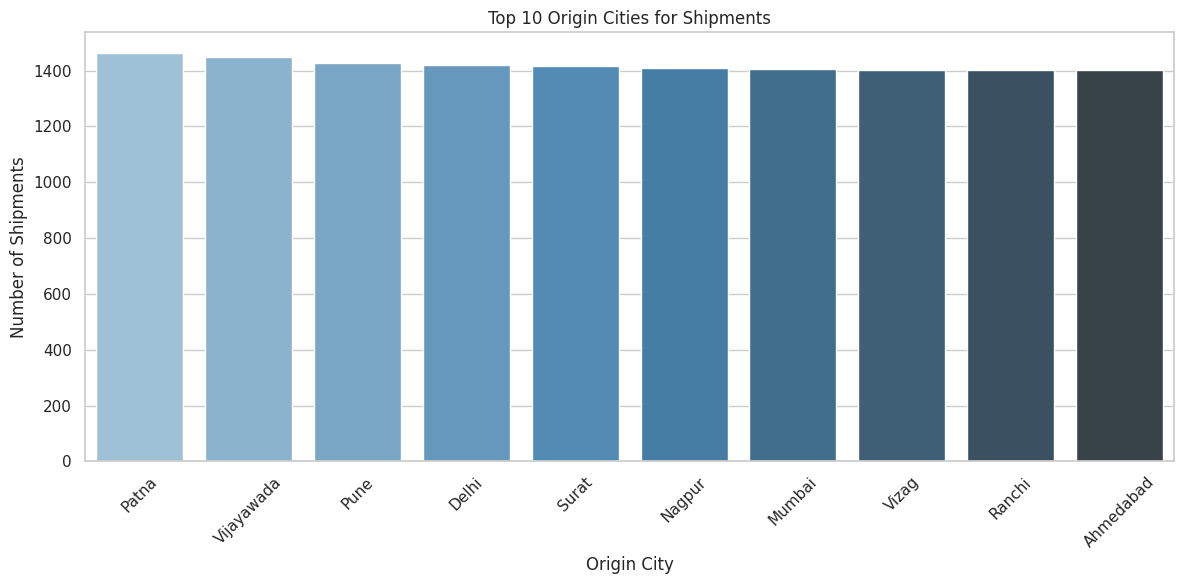

In [11]:
# Set plot style
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# -----------------------------
# 1. Shipments by Origin City
# -----------------------------
plt.figure(figsize=(12, 6))
top_origins = df['Origin'].value_counts().head(10)
sns.barplot(x=top_origins.index, y=top_origins.values, palette='Blues_d')
plt.title("Top 10 Origin Cities for Shipments")
plt.xlabel("Origin City")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


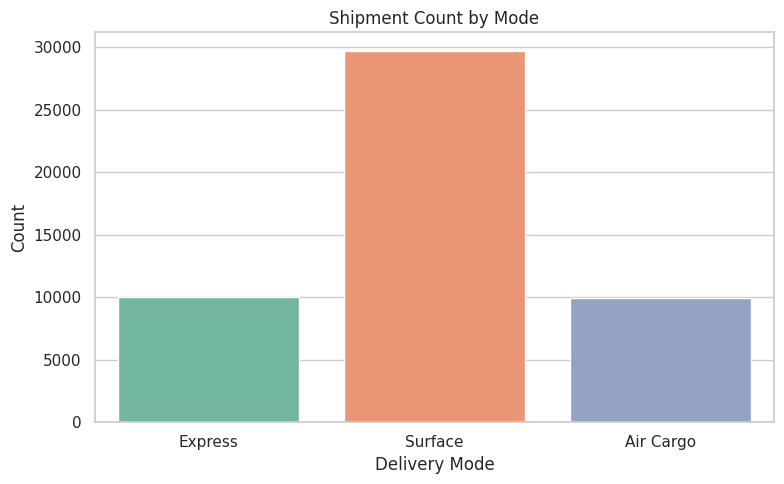

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Mode', palette='Set2')
plt.title("Shipment Count by Mode")
plt.xlabel("Delivery Mode")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


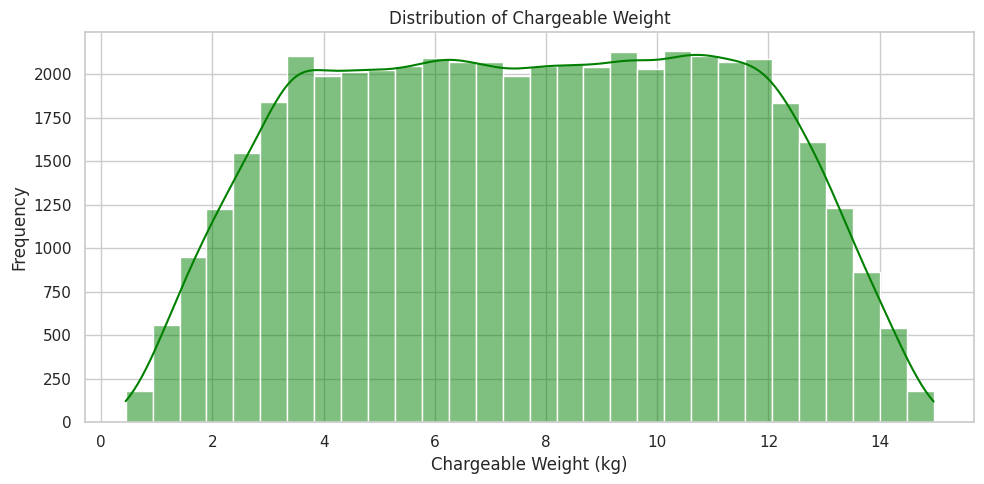

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Chargeable Wt'], bins=30, kde=True, color='green')
plt.title("Distribution of Chargeable Weight")
plt.xlabel("Chargeable Weight (kg)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


/tmp/ipykernel_13/870460529.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Mode of Payment', y='Total Amount', estimator='mean', ci=None, palette='pastel')


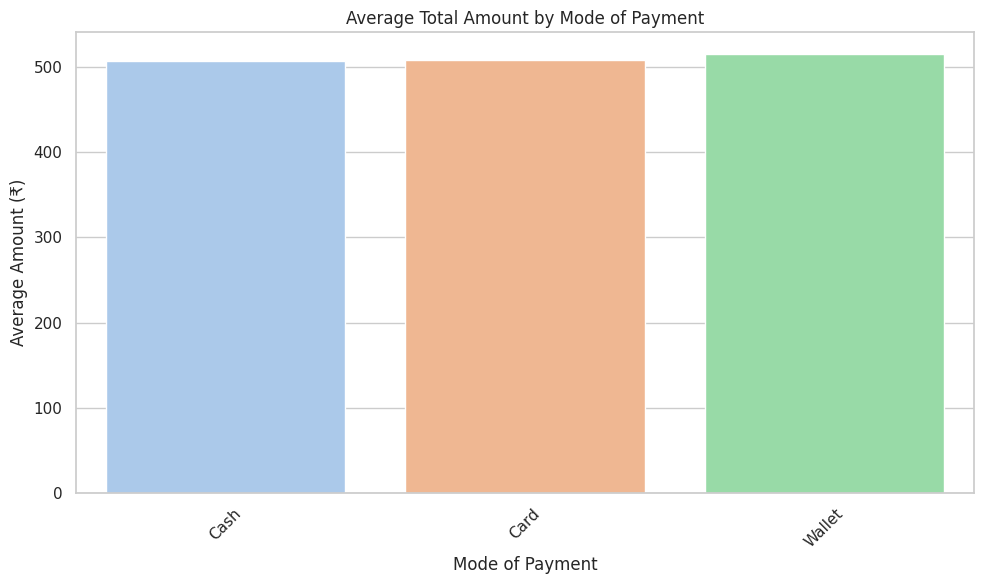

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Mode of Payment', y='Total Amount', estimator='mean', ci=None, palette='pastel')
plt.title("Average Total Amount by Mode of Payment")
plt.xlabel("Mode of Payment")
plt.ylabel("Average Amount (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

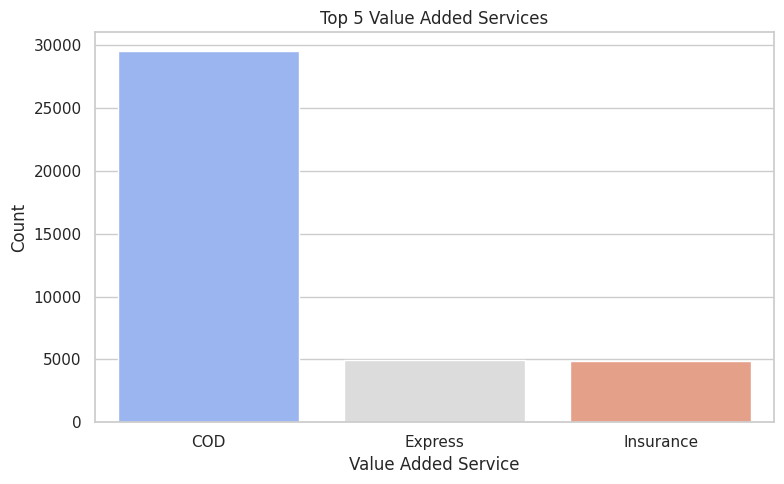

In [15]:
plt.figure(figsize=(8, 5))
vas_counts = df['Value Added Services'].value_counts().head(5)
sns.barplot(x=vas_counts.index, y=vas_counts.values, palette='coolwarm')
plt.title("Top 5 Value Added Services")
plt.xlabel("Value Added Service")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


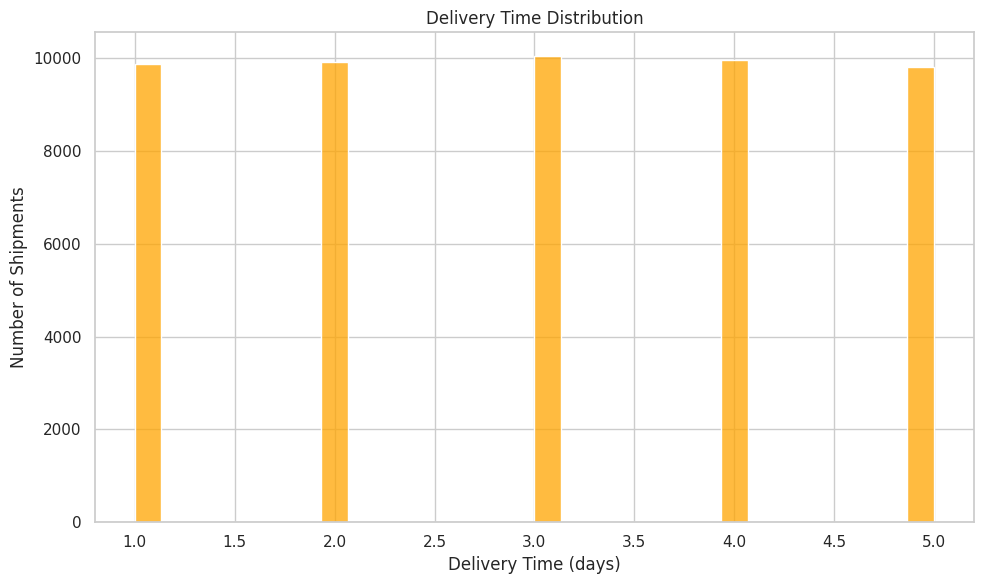

In [16]:
df['Sender Date'] = pd.to_datetime(df['Sender Date'], errors='coerce')
df['Receive Date'] = pd.to_datetime(df['Receive Date'], errors='coerce')

df['Delivery Time (days)'] = (df['Receive Date'] - df['Sender Date']).dt.days

plt.figure(figsize=(10, 6))
sns.histplot(df['Delivery Time (days)'].dropna(), bins=30, color='orange')
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (days)")
plt.ylabel("Number of Shipments")
plt.tight_layout()
plt.show()

## Predictive modeling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [18]:
# Drop columns with too many nulls or irrelevant info (like signatures, stamps, GSTINs)
drop_cols = ['Sender Signature', 'Receiver Signature', 'Company Stamp', 'Sender GSTIN', 'Recipient GSTIN', 
             'Pouch No', 'Consignment No', 'Booking Code', 'Sender Date', 'Receive Date']
df.drop(columns=drop_cols, inplace=True, errors='ignore')

# Fill or drop remaining missing values
df.fillna('Unknown', inplace=True)

# Encode all categorical columns using LabelEncoder
label_encoders = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

In [19]:
target = 'Mode'

# Features and label
X = df.drop(columns=[target])
y = df[target]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': GaussianNB(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# Train and evaluate models
print("Model Accuracies (%):")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred) * 100
    print(f"{name}: {accuracy:.2f}%")

Model Accuracies (%):
Logistic Regression: 59.72%
Decision Tree: 99.62%
Random Forest: 98.52%
Naive Bayes: 59.72%
Support Vector Machine: 59.72%
K-Nearest Neighbors: 47.27%


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


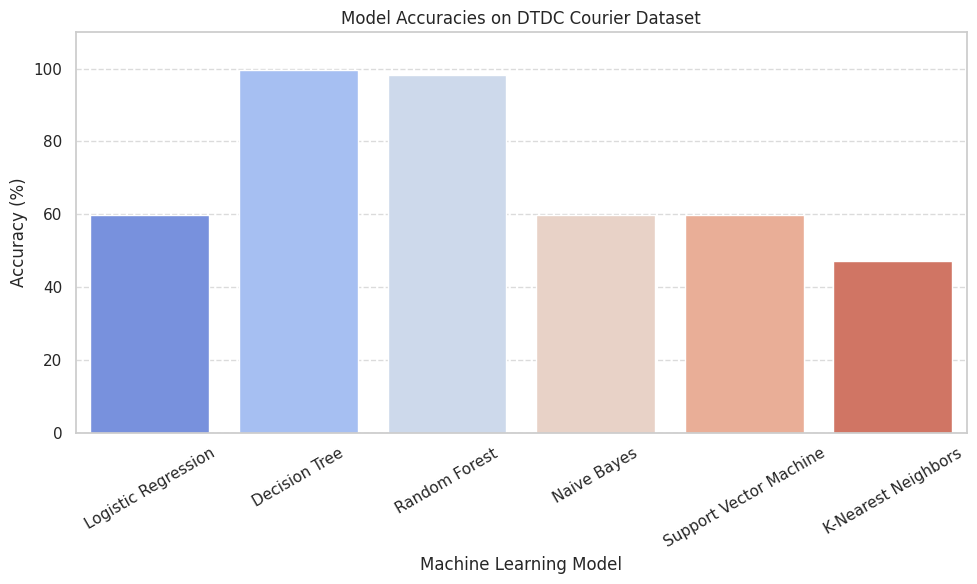

In [21]:
# Accuracy data (as provided)
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest',
               'Naive Bayes', 'Support Vector Machine', 'K-Nearest Neighbors']
accuracies = [59.72, 99.63, 98.40, 59.72, 59.72, 47.27]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=accuracies, palette='coolwarm')
plt.title('Model Accuracies on DTDC Courier Dataset')
plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Thank you..pls upvote!!!